# AQI Forecasting — Feature Engineering & Model Experiments

A learning-oriented, production-shaped notebook for forecasting AQI N days ahead
from pollutant + weather history. Every section explains **what** it does, **why**
it's structured that way, and **how** the code works — written so someone opening
this repo cold (including future-you) can follow it without side context.

**Design principles used throughout:**
- **Modular over hardcoded.** Nearly everything is a function that takes the
  forecast horizon, the split strategy, or the model as a parameter, instead of a
  notebook that only works for `aqi_next_1d` and breaks the moment you change it.
- **Every model goes through the same evaluation path.** One `evaluate_and_log()`
  and one `plot_model_diagnostics()` function are reused for every model, so
  results are directly comparable and you only have to learn to read one set of
  plots.
- **Delta-target throughout.** Every model predicts *change* in AQI
  (`aqi_next_Nd - european_aqi`), not the raw level — explained in Section 9.

1. Setup
2. API Client Layer — pass a city name, coordinates are resolved automatically
3. Data Validation Layer
4. Feature Engineering Layer
5. Quick Smoke Test
6. Historical Data Pipeline
7. Exploratory Data Analysis
8. Outlier Assessment & Handling
9. Target & Split Utilities — the modular horizon/split machinery
10. Model Training & Diagnostics Framework — one function, every model
11. Baseline Models: Random Forest & Ridge
12. XGBoost
13. Hyperparameter Tuning — GridSearchCV & RandomizedSearchCV
14. Walk-Forward Validation
15. Deep Learning: Feed-Forward NN & LSTM
16. Multi-Horizon Comparison (1-day / 2-day / 3-day ahead)
17. Model Leaderboard
18. Next Steps


# 01 — Exploratory Data Analysis & Validation

Exploratory Data Analysis, API Client, and Data Validation for Pearls AQI Predictor.


## 1. Setup

In [ ]:
!pip install openmeteo_requests requests_cache retry_requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.4/230.4 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.9/809.9 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.4/131.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 111.1 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


In [ ]:
# --- stdlib ---
from abc import ABC, abstractmethod
from datetime import datetime
from typing import Any, Dict, List, Optional

# --- data & viz ---
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- API client ---
import openmeteo_requests
import requests_cache
from retry_requests import retry
from requests.exceptions import HTTPError

# --- validation ---
from pydantic import BaseModel, Field, field_validator, ValidationError

# --- sklearn ---
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error,
)

# --- xgboost ---
import xgboost as xgb

# --- deep learning ---
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

sns.set_theme(style="whitegrid")

# A running scoreboard. Every call to evaluate_and_log() (Section 10) appends one
# row here — this IS the notebook's source of truth for "which model won," so it
# gets reset at the top of every fresh run instead of silently accumulating rows
# across kernel sessions (that's an easy way to end up reporting stale numbers).
leaderboard = []

## 2. API Client Layer

**What this does:** wraps Open-Meteo's two APIs (air quality + historical weather)
behind one interface, and resolves a **city name** to coordinates internally so the
rest of the notebook never has to know or care about lat/lon.

**Why a city dictionary instead of a geocoding API call:** an extra network request
per city lookup is pure overhead for a fixed, known set of cities you're actually
going to use. A dictionary is one lookup, zero latency, zero failure mode. Add a
city once (`CITY_COORDINATES["your_city"] = (lat, lon)`) and every function below
picks it up automatically.

**Why an abstract base class for a single client:** `OpenMeteoClient` isn't the
only air-quality provider that will ever exist. Coding against `BaseAPIClient`
instead of `OpenMeteoClient` directly means adding a second provider later (a paid
fallback, a different region's better-covered source) is one new subclass, not a
rewrite of every place that calls `client.fetch_historical(...)`. This is the
**Strategy pattern**: the caller depends on the interface, not the implementation.

In [ ]:
# Known cities — add more as needed. Keys are lowercased for lookup;
# CITY_COORDINATES["lahore"] and CITY_COORDINATES["Lahore"] both resolve.
CITY_COORDINATES: Dict[str, tuple] = {
    "lahore": (31.558, 74.351),
    "karachi": (24.8607, 67.0011),
    "islamabad": (33.6844, 73.0479),
    "delhi": (28.6139, 77.2090),
    "beijing": (39.9042, 116.4074),
    "new york": (40.7128, -74.0060),
    "london": (51.5074, -0.1278),
    "los angeles": (34.0522, -118.2437),
}

def resolve_city(city: str) -> tuple:
    """Look up (lat, lon) for a known city name. Raises a clear error for an
    unknown one instead of silently failing deep inside an API call."""
    key = city.strip().lower()
    if key not in CITY_COORDINATES:
        known = ", ".join(sorted(CITY_COORDINATES))
        raise ValueError(f"Unknown city '{city}'. Known cities: {known}. "
                          f"Add it to CITY_COORDINATES to use it.")
    return CITY_COORDINATES[key]

In [ ]:
AQI_VARIABLES = [
    "pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide",
    "sulphur_dioxide", "ozone", "uv_index", "aerosol_optical_depth", "european_aqi",
]

WEATHER_VARIABLES = [
    "temperature_2m", "wind_direction_10m", "wind_speed_10m", "rain",
    "weather_code", "wind_gusts_10m", "cloud_cover", "relative_humidity_2m",
]


class BaseAPIClient(ABC):
    """Abstract base for all API clients — every provider implements the same
    four methods, so the rest of the notebook only ever talks to this interface."""

    def __init__(self, api_key: str = None):
        self.api_key = api_key

    @abstractmethod
    def fetch_current(self, city: str) -> Dict[str, Any]:
        pass

    @abstractmethod
    def fetch_historical(self, city: str, start_date: str, end_date: str) -> list:
        pass

    @abstractmethod
    def fetch_current_weather(self, city: str) -> Dict[str, Any]:
        pass

    @abstractmethod
    def fetch_historical_weather(self, city: str, start_date: str, end_date: str) -> list:
        pass


class OpenMeteoClient(BaseAPIClient):
    """Open-Meteo air-quality + weather client. No API key needed."""

    AQI_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"
    WEATHER_URL = "https://api.open-meteo.com/v1/forecast"
    WEATHER_HISTORY_URL = "https://archive-api.open-meteo.com/v1/archive"

    def __init__(self):
        super().__init__()
        cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
        retry_session = retry(cache_session, retries=3, backoff_factor=0.2)
        self.client = openmeteo_requests.Client(session=retry_session)

    # ---- shared internals --------------------------------------------------

    def _fetch_current(self, url: str, variables: List[str], city: str,
                        lat: float, lon: float) -> Dict[str, Any]:
        params = {"latitude": lat, "longitude": lon, "current": variables, "timezone": "auto"}
        print(f"Fetching current data from {url} for {city} ({lat}, {lon})")
        try:
            response = self.client.weather_api(url, params=params)[0]
            current = response.Current()
            data = {
                "date": pd.to_datetime(current.Time(), unit="s", utc=True)
                    .tz_convert(response.Timezone().decode()).tz_localize(None),
                "city": city, "lat": lat, "lon": lon,
            }
            data.update({var: round(current.Variables(i).Value(), 5) for i, var in enumerate(variables)})
            return data
        except Exception as e:
            print(f"Request failed: {e}")
            raise HTTPError(f"OpenMeteo current request failed ({url}): {e}")

    def _fetch_historical(self, url: str, variables: List[str], city: str,
                           lat: float, lon: float, start_date: str, end_date: str) -> list:
        params = {
            "latitude": lat, "longitude": lon, "hourly": variables,
            "timezone": "auto", "start_date": start_date, "end_date": end_date,
        }
        print(f"Fetching historical data from {url} for {city} [{start_date} -> {end_date}]")
        try:
            response = self.client.weather_api(url, params=params)[0]
            hourly = response.Hourly()
            hourly_data = {
                "date": pd.date_range(
                    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
                    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
                    freq=pd.Timedelta(seconds=hourly.Interval()),
                    inclusive="left",
                ).tz_convert(response.Timezone().decode()),
                "city": city, "lat": lat, "lon": lon,
            }
            for i, var in enumerate(variables):
                hourly_data[var] = hourly.Variables(i).ValuesAsNumpy()
            return pd.DataFrame(hourly_data).to_dict(orient="records")
        except Exception as e:
            print(f"Request failed: {e}")
            raise HTTPError(f"OpenMeteo historical request failed ({url}): {e}")

    # ---- public API — all take a city NAME, coordinates resolved internally ---

    def fetch_current(self, city: str) -> Dict[str, Any]:
        lat, lon = resolve_city(city)
        return self._fetch_current(self.AQI_URL, AQI_VARIABLES, city, lat, lon)

    def fetch_historical(self, city: str, start_date: str, end_date: str) -> list:
        lat, lon = resolve_city(city)
        return self._fetch_historical(self.AQI_URL, AQI_VARIABLES, city, lat, lon, start_date, end_date)

    def fetch_current_weather(self, city: str) -> Dict[str, Any]:
        lat, lon = resolve_city(city)
        return self._fetch_current(self.WEATHER_URL, WEATHER_VARIABLES, city, lat, lon)

    def fetch_historical_weather(self, city: str, start_date: str, end_date: str) -> list:
        lat, lon = resolve_city(city)
        return self._fetch_historical(self.WEATHER_HISTORY_URL, WEATHER_VARIABLES, city, lat, lon, start_date, end_date)


class APIClientFactory:
    """Factory for the active client — swap providers here without touching
    anything that calls client.fetch_historical(...) elsewhere in the notebook."""

    @staticmethod
    def get_primary_client() -> BaseAPIClient:
        return OpenMeteoClient()

In [ ]:
client = APIClientFactory.get_primary_client()
CITY = "Lahore"   # change this one line to point the whole notebook at another city

## 3. Data Validation Layer

**What this does:** two checks, run at two different points in the pipeline.
`validate_raw_data` checks the API response *before* any feature engineering
touches it — wrong types, impossible values (negative concentrations, AQI outside
0-500), too many nulls. `validate_features` runs *after* feature engineering and
checks for **drift**: do the engineered features still look like what the model was
trained on, statistically?

**Why validate before AND after:** a bug in the API response and a bug in your own
feature engineering look identical downstream (a model that's suddenly wrong) but
need different fixes. Catching each at its own boundary tells you immediately which
side of the pipeline broke.

In [ ]:
class RawDataSchema(BaseModel):
    """Validates one row of raw API response before feature engineering."""
    date: datetime
    city: str
    lat: float
    lon: float
    temperature_2m: Optional[float] = Field(None)
    wind_direction_10m: Optional[float] = Field(None)
    wind_speed_10m: Optional[float] = Field(None)
    rain: Optional[float] = Field(None)
    weather_code: Optional[float] = Field(None)
    wind_gusts_10m: Optional[float] = Field(None)
    cloud_cover: Optional[float] = Field(None)
    relative_humidity_2m: Optional[float] = Field(None)
    pm10: Optional[float] = Field(None, ge=0)
    pm2_5: Optional[float] = Field(None, ge=0)
    carbon_monoxide: Optional[float] = Field(None, ge=0)
    nitrogen_dioxide: Optional[float] = Field(None, ge=0)
    sulphur_dioxide: Optional[float] = Field(None, ge=0)
    ozone: Optional[float] = Field(None, ge=0)
    uv_index: Optional[float] = Field(None, ge=0)
    aerosol_optical_depth: Optional[float] = Field(None, ge=0)
    european_aqi: float = Field(..., ge=0, le=500)

    @field_validator("european_aqi")
    @classmethod
    def aqi_must_be_reasonable(cls, v):
        if v > 300:
            print(f"Extremely high AQI detected: {v}")
        return v


class DataValidator:
    """Validates DataFrames against the schema above and a few business rules."""

    def validate_raw_data(self, df: pd.DataFrame) -> pd.DataFrame:
        validation_errors = []
        for idx, row in df.iterrows():
            try:
                RawDataSchema(**row.to_dict())
            except ValidationError as e:
                for err_dict in e.errors():
                    validation_errors.append({
                        **err_dict,
                        "loc": ("row", idx, *err_dict.get("loc", ())),
                        "input": row.to_dict(),
                    })
        if validation_errors:
            raise ValidationError.from_exception_data("RawDataSchema validation", validation_errors)

        null_rates = df.isnull().mean() * 100
        bad_cols = null_rates[null_rates > 5]
        if not bad_cols.empty:
            raise ValueError(f"Columns exceed 5% null rate: {bad_cols.to_dict()}")

        out_of_range = ~df["european_aqi"].between(0, 500)
        if out_of_range.any():
            raise ValueError(f"{out_of_range.sum()} row(s) with european_aqi out of [0, 500]")

        return df

    def build_reference_stats(self, train_df: pd.DataFrame) -> dict:
        """Snapshot of each numeric column's mean/std, taken from TRAINING data
        only. This is what validate_features() below compares new data against —
        it's the "what normal looks like" baseline."""
        columns = train_df.select_dtypes(include=["number"]).columns
        return {col: {"mean": train_df[col].mean(), "std": train_df[col].std()} for col in columns}

    def validate_features(self, df: pd.DataFrame, reference_stats: dict = None) -> pd.DataFrame:
        """Flags any column whose current mean has drifted more than 3 standard
        deviations (measured in the reference/training scale) from what training
        data looked like. A print, not a hard failure — drift is a signal to go
        look, not necessarily a broken pipeline (a real smog event SHOULD drift
        the pollutant columns; that's not a bug)."""
        if reference_stats is None:
            print("No reference stats provided — skipping drift check.")
            return df
        for col, stats in reference_stats.items():
            if col not in df.columns:
                continue
            current_mean = df[col].mean()
            if stats["std"] > 0:
                drift = abs(current_mean - stats["mean"]) / stats["std"]
                if drift > 3:
                    print(f"Feature drift detected in '{col}': current mean={current_mean:.2f}, reference mean={stats['mean']:.2f}")
        return df

## 5. Quick Smoke Test

One live reading through client → validator → feature-engineer, to confirm the
pieces fit together before pulling years of historical data. Variables are
`demo_`-prefixed so nothing here collides with the real pipeline below.

In [ ]:
demo_current_aqi = client.fetch_current(CITY)
demo_current_weather = client.fetch_current_weather(CITY)
demo_row = {**demo_current_weather, **demo_current_aqi}
demo_row

Fetching current data from https://air-quality-api.open-meteo.com/v1/air-quality for Lahore (31.558, 74.351)
Fetching current data from https://api.open-meteo.com/v1/forecast for Lahore (31.558, 74.351)


{'date': Timestamp('2026-08-08 12:00:00'),
 'city': 'Lahore',
 'lat': 31.558,
 'lon': 74.351,
 'temperature_2m': 32.2,
 'wind_direction_10m': 117.75845,
 'wind_speed_10m': 7.72953,
 'rain': 0.0,
 'weather_code': 3.0,
 'wind_gusts_10m': 24.12,
 'cloud_cover': 80.0,
 'relative_humidity_2m': 64.0872,
 'pm10': 29.7,
 'pm2_5': 28.7,
 'carbon_monoxide': 412.0,
 'nitrogen_dioxide': 16.9,
 'sulphur_dioxide': 11.8,
 'ozone': 108.0,
 'uv_index': 3.55,
 'aerosol_optical_depth': 0.49,
 'european_aqi': 79.94666}

In [ ]:
validator = DataValidator()

demo_df = pd.DataFrame([demo_row])
demo_validated_df = validator.validate_raw_data(demo_df)
demo_validated_df

,date,city,lat,lon,temperature_2m,wind_direction_10m,wind_speed_10m,rain,weather_code,wind_gusts_10m,...,relative_humidity_2m,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,uv_index,aerosol_optical_depth,european_aqi
0,2026-08-08 12:00:00,Lahore,31.558,74.351,32.2,117.75845,7.72953,0.0,3.0,24.12,...,64.0872,29.7,28.7,412.0,16.9,11.8,108.0,3.55,0.49,79.94666


In [ ]:
demo_feature_engineer = AQIFeatureEngineer()
demo_features_df = demo_feature_engineer.fit_transform(demo_validated_df)
demo_features_df.columns

Index(['date', 'city', 'lat', 'lon', 'temperature_2m', 'wind_direction_10m',
       'wind_speed_10m', 'rain', 'weather_code', 'wind_gusts_10m',
       'cloud_cover', 'relative_humidity_2m', 'pm10', 'pm2_5',
       'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone',
       'uv_index', 'aerosol_optical_depth', 'european_aqi', 'hour',
       'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'wind_u', 'wind_v', 'pm_ratio',
       'no2_o3_ratio', 'temp_trend_7d', 'rain_accum_7d', 'aqi_lag_1h',
       'aqi_lag_3h', 'aqi_lag_24h', 'aqi_roll_mean_6h', 'aqi_roll_std_6h',
       'aqi_roll_mean_12h', 'aqi_roll_std_12h', 'aqi_roll_mean_24h',
       'aqi_roll_std_24h', 'aqi_ewm_6h', 'aqi_change_1h', 'aqi_change_24h',
       'aqi_next_1d'],
      dtype='object')

## 6. Historical Data Pipeline

Pulls several years of hourly pollutant + weather data for `CITY` and merges them
on `date`. Multi-year history matters here for a specific reason: with only a
couple months of data, whichever chunk lands in the test split could be an
unrepresentative one-off (a single rain event, say), and R² would swing wildly
depending on which weeks you happened to test on. Years of data means both train
and test see a realistic mix of seasons.

In [ ]:
START_DATE, END_DATE = "2023-01-01", "2026-07-31"

history_aqi = client.fetch_historical(CITY, START_DATE, END_DATE)
history_aqi_df = pd.DataFrame(history_aqi)

history_weather = client.fetch_historical_weather(CITY, START_DATE, END_DATE)
history_weather_df = pd.DataFrame(history_weather)

Fetching historical data from https://air-quality-api.open-meteo.com/v1/air-quality for Lahore [2023-01-01 -> 2026-07-31]
Fetching historical data from https://archive-api.open-meteo.com/v1/archive for Lahore [2023-01-01 -> 2026-07-31]


In [ ]:
merged_df = pd.merge(history_weather_df, history_aqi_df, on=["date", "city", "lat", "lon"])
merged_df.to_csv("./Historical_AQI_and_Weather_data.csv", index=False)
merged_df.head()

,date,city,lat,lon,temperature_2m,wind_direction_10m,wind_speed_10m,rain,weather_code,wind_gusts_10m,...,relative_humidity_2m,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,uv_index,aerosol_optical_depth,european_aqi
0,2023-01-01 00:00:00+05:00,Lahore,31.558,74.351,9.05,301.429504,7.594208,0.0,3.0,12.24,...,88.799934,158.800003,111.099998,4479.0,122.949997,25.049999,0.0,0.0,0.22,99.970001
1,2023-01-01 01:00:00+05:00,Lahore,31.558,74.351,9.00,311.185822,7.653705,0.0,3.0,12.24,...,89.099777,143.899994,100.599998,3661.0,112.099998,22.150000,1.0,0.0,0.22,101.206657
2,2023-01-01 02:00:00+05:00,Lahore,31.558,74.351,8.65,306.869965,7.200000,0.0,3.0,12.24,...,90.299522,136.399994,95.199997,2781.0,98.650002,19.400000,2.0,0.0,0.21,102.246666
3,2023-01-01 03:00:00+05:00,Lahore,31.558,74.351,8.55,318.814148,7.653705,0.0,3.0,12.24,...,90.912437,136.399994,95.199997,2443.0,88.900002,19.000000,3.0,0.0,0.21,103.276665
4,2023-01-01 04:00:00+05:00,Lahore,31.558,74.351,7.55,329.036316,6.297428,0.0,2.0,12.24,...,92.740280,140.600006,98.000000,2267.0,79.550003,19.500000,3.0,0.0,0.21,104.469986


In [ ]:
raw_df = pd.read_csv("./Historical_AQI_and_Weather_data.csv")
raw_df["date"] = pd.to_datetime(raw_df["date"])
raw_df = validator.validate_raw_data(raw_df)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31392 entries, 0 to 31391
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype                    
---  ------                 --------------  -----                    
 0   date                   31392 non-null  datetime64[ns, UTC+05:00]
 1   city                   31392 non-null  object                   
 2   lat                    31392 non-null  float64                  
 3   lon                    31392 non-null  float64                  
 4   temperature_2m         31392 non-null  float64                  
 5   wind_direction_10m     31392 non-null  float64                  
 6   wind_speed_10m         31392 non-null  float64                  
 7   rain                   31392 non-null  float64                  
 8   weather_code           31392 non-null  float64                  
 9   wind_gusts_10m         31392 non-null  float64                  
 10  cloud_cover            31392 non-null  float64

In [ ]:
MAX_HORIZON = 3   # build targets for every horizon we might want (1d, 2d, 3d) in one pass

feature_engineer = AQIFeatureEngineer(forecast_horizon=MAX_HORIZON)
engineered_df = feature_engineer.fit_transform(raw_df)
engineered_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31392 entries, 0 to 31391
Data columns (total 52 columns):
 #   Column                 Non-Null Count  Dtype                    
---  ------                 --------------  -----                    
 0   date                   31392 non-null  datetime64[ns, UTC+05:00]
 1   city                   31392 non-null  object                   
 2   lat                    31392 non-null  float64                  
 3   lon                    31392 non-null  float64                  
 4   temperature_2m         31392 non-null  float64                  
 5   wind_direction_10m     31392 non-null  float64                  
 6   wind_speed_10m         31392 non-null  float64                  
 7   rain                   31392 non-null  float64                  
 8   weather_code           31392 non-null  float64                  
 9   wind_gusts_10m         31392 non-null  float64                  
 10  cloud_cover            31392 non-null  float64

In [ ]:
reference_dict = validator.build_reference_stats(
    engineered_df.drop(columns=["date", "city", "lat", "lon"]).select_dtypes(include="number")
)
engineered_df = validator.validate_features(engineered_df, reference_dict)

## 7. Exploratory Data Analysis

Five plots, each answering a different question a reviewer would actually ask
before trusting a forecasting model:

1. **Time series** — does AQI have visible seasonality/trend?
2. **Monthly box plots** — where do outliers live, and are they a data problem or
   a real seasonal pattern?
3. **Distributions** — which features are skewed enough that a linear model
   (Ridge) might struggle with them as-is?
4. **Correlation heatmap + redundancy check** — which features move together?
5. **Autocorrelation (ACF)** — how many hours back does AQI actually "remember"
   itself? This is the empirical justification for the lag/rolling windows chosen
   in Section 4, instead of picking 1h/3h/24h just because they sounded reasonable.

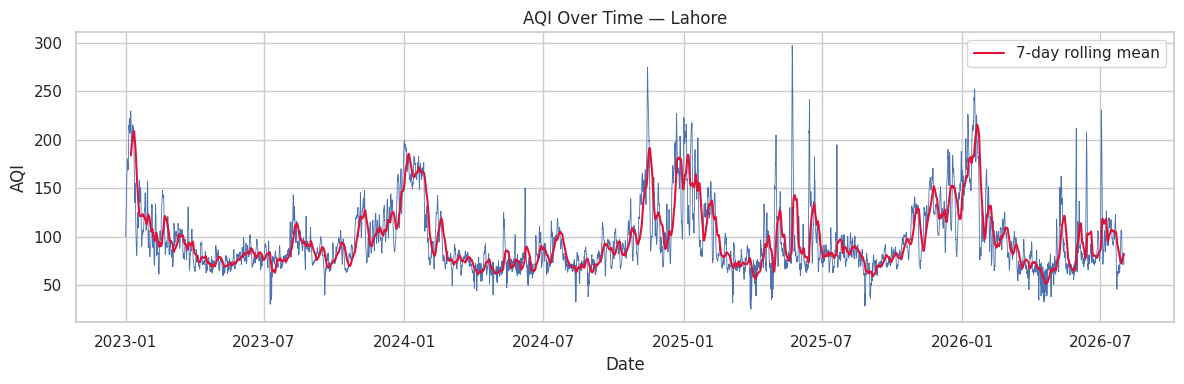

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(engineered_df['date'], engineered_df['european_aqi'], linewidth=0.6)
plt.plot(engineered_df['date'], engineered_df['european_aqi'].rolling(24 * 7).mean(),
          color='crimson', linewidth=1.5, label='7-day rolling mean')
plt.title(f'AQI Over Time — {CITY}')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.show()

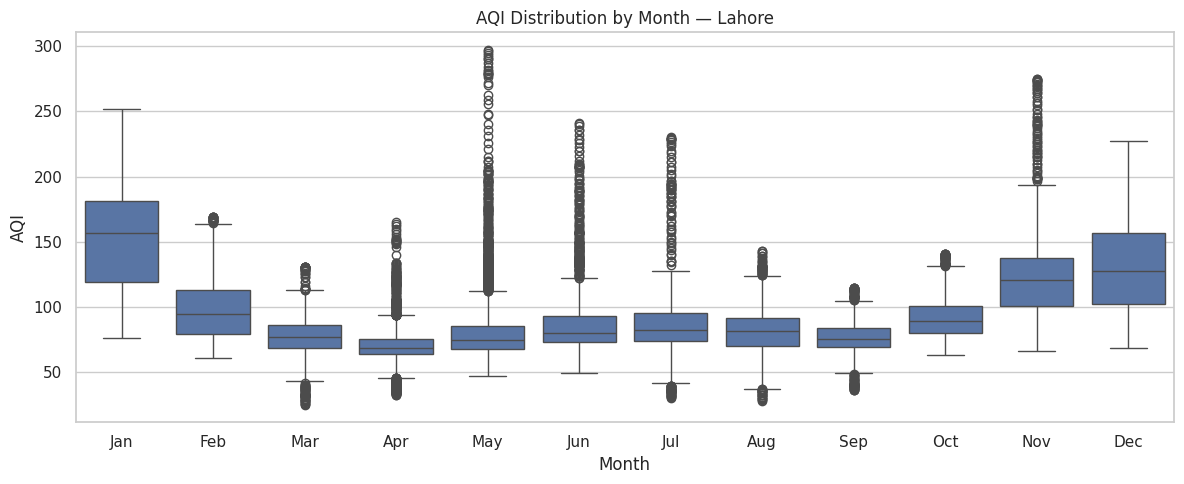

In [ ]:
# Monthly box plots — this is the plot that answers "are those outliers real?"
# A box plot per calendar month shows whether high values cluster in a specific
# season (real seasonal pollution, e.g. winter smog) or scatter randomly across
# the whole year (more likely to include sensor glitches — see Section 8).
plot_df = engineered_df.copy()
plot_df['month_name'] = plot_df['date'].dt.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
sns.boxplot(data=plot_df, x='month_name', y='european_aqi', order=month_order)
plt.title(f'AQI Distribution by Month — {CITY}')
plt.xlabel('Month')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()

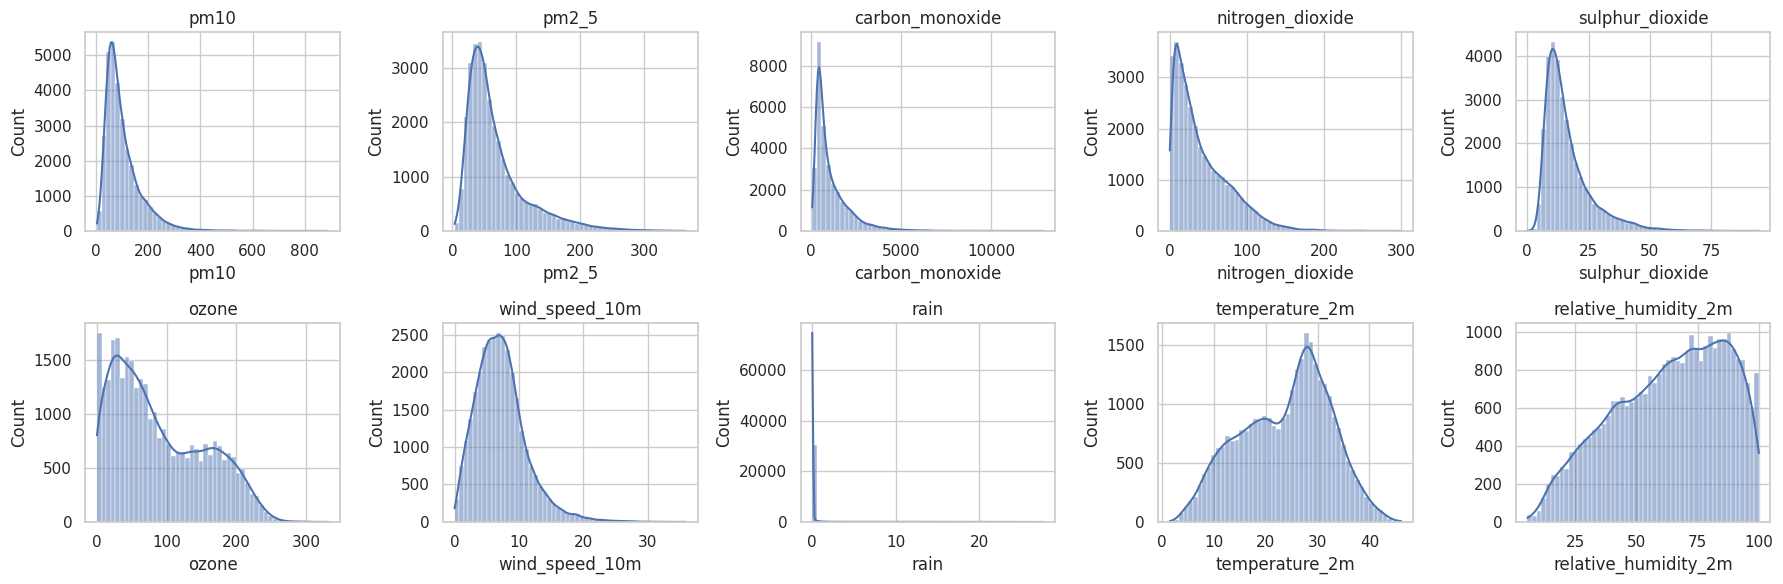

In [ ]:
# Distribution grid for the raw pollutant + weather features that feed the model.
# Skewed distributions (long right tails) are exactly what makes Ridge/NN sensitive
# to outliers — trees don't care about this, linear/gradient models do.
dist_cols = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide',
             'ozone', 'wind_speed_10m', 'rain', 'temperature_2m', 'relative_humidity_2m']

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, col in zip(axes.flat, dist_cols):
    sns.histplot(engineered_df[col], bins=50, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

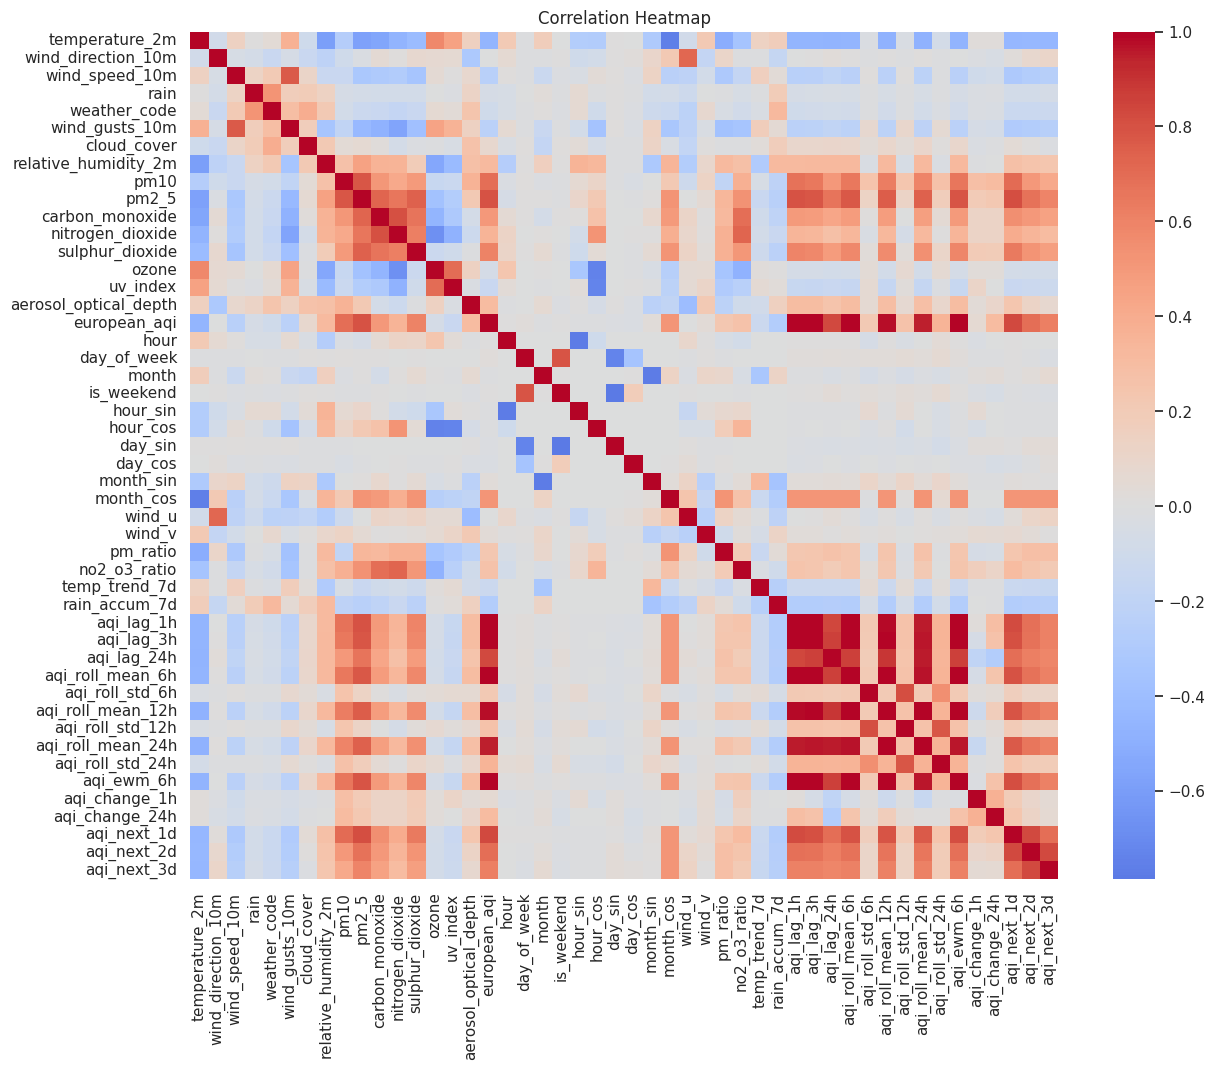

In [ ]:
num_df = engineered_df.select_dtypes(include=['number']).drop(columns=['lat', 'lon'])
corr = num_df.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Which feature pairs are genuinely redundant (|corr| > 0.9)?
# Expected here: european_aqi and its own lags/rolling means will correlate above
# 0.9 with each other — they're smoothed copies of the same series. That's not a
# bug. For tree models, keep all of them (trees don't destabilize from
# collinearity — the cost is diluted feature_importances_, an interpretability
# issue). For Ridge, keep them too — L2 regularization exists
# specifically to handle correlated predictors gracefully.
target_horizon_cols = [c for c in corr.columns if c.startswith('aqi_next_')]
pairs = []
cols = [c for c in corr.columns if c not in target_horizon_cols]
for i, a in enumerate(cols):
    for b in cols[i + 1:]:
        c = corr.loc[a, b]
        if abs(c) > 0.9:
            pairs.append((a, b, round(c, 3)))
pairs.sort(key=lambda p: -abs(p[2]))
pd.DataFrame(pairs, columns=['feature_a', 'feature_b', 'correlation'])

,feature_a,feature_b,correlation
0,aqi_lag_3h,aqi_roll_mean_6h,1.000
1,european_aqi,aqi_lag_1h,0.999
2,aqi_lag_1h,aqi_ewm_6h,0.999
3,aqi_lag_3h,aqi_ewm_6h,0.999
4,aqi_roll_mean_6h,aqi_ewm_6h,0.999
5,aqi_lag_1h,aqi_lag_3h,0.997
6,european_aqi,aqi_ewm_6h,0.996
7,aqi_lag_1h,aqi_roll_mean_6h,0.996
8,aqi_roll_mean_6h,aqi_roll_mean_12h,0.995
9,european_aqi,aqi_lag_3h,0.993


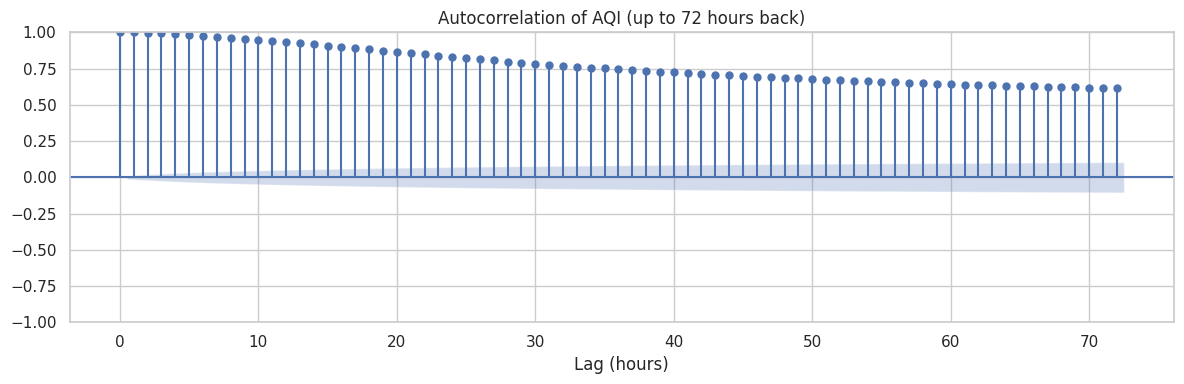

In [ ]:
# Autocorrelation of AQI itself — how far back does it "remember"?
# This is the empirical check behind the lag/rolling windows chosen in Section 4:
# if ACF is still high at lag 24, a same-hour-yesterday feature is earning its keep.
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(engineered_df['european_aqi'].dropna(), lags=72, ax=ax)
ax.set_title('Autocorrelation of AQI (up to 72 hours back)')
ax.set_xlabel('Lag (hours)')
plt.tight_layout()
plt.show()

## 8. Outlier Assessment & Handling

The box plots above show real outliers — but **"outlier" doesn't automatically
mean "remove it."** There are two different things hiding under that one word here,
and they need opposite treatment:

- **Genuine extreme pollution events** (a severe winter smog day pushing AQI past
  250) are exactly the tail behavior a forecasting model needs to learn. Dropping
  these rows would make the model *worse* at the thing it's most useful for —
  warning about bad air days.
- **Physically implausible sensor spikes** (`pm10` hitting 890 µg/m³, `carbon_monoxide`
  spiking past 12,000 — both far beyond anything a real dust storm or traffic jam
  produces) are far more likely instrument glitches than real air. These add pure
  noise: a tree might carve out a useless split just to isolate one glitch row, and
  a linear/NN model's scaling gets dragged by a handful of extreme points.

**The fix used here: cap (winsorize), don't drop.** Dropping a row loses that
timestamp's lag/rolling context for every neighboring row too (since those windows
span it). Capping at a high percentile keeps every row and every timestamp, and
only pulls in the physically-implausible tail.

**Why the cap threshold comes from `TRAIN_END_IDX` and not the whole dataset:**
if you compute the 99.5th percentile from the *full* dataset (train + test), the
test set's own values sneak into a statistic used to preprocess the training set —
a subtle form of the same leakage problem as fitting a scaler on test data.

**`european_aqi` itself is deliberately NOT capped** — its extremes are the real
target signal (see the point above), not noise to smooth out. Only the raw
pollutant *inputs* prone to sensor glitches get capped.

In [ ]:
OUTLIER_CAP_COLUMNS = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide']

def cap_outliers(df: pd.DataFrame, columns: List[str], train_end_idx: int,
                  upper_q: float = 0.995) -> tuple:
    """Clips each column at its (upper_q) percentile, computed from the
    TRAINING portion only (rows before train_end_idx). Returns the modified
    dataframe and the thresholds used, so you can inspect what got capped."""
    df = df.copy()
    thresholds = {}
    train_part = df.iloc[:train_end_idx]
    for col in columns:
        hi = train_part[col].quantile(upper_q)
        thresholds[col] = hi
        n_capped = (df[col] > hi).sum()
        print(f"{col:20s} capped at {hi:9.2f}  ({n_capped} rows affected, "
              f"{100 * n_capped / len(df):.2f}%)")
        df[col] = df[col].clip(upper=hi)
    return df, thresholds


# Cap is computed on the first 80% chronologically — matches the holdout split
# used later, so the threshold is genuinely "train-only" information.
_train_end_idx = int(len(engineered_df) * 0.8)
engineered_df, outlier_thresholds = cap_outliers(engineered_df, OUTLIER_CAP_COLUMNS, _train_end_idx)

pm10                 capped at    409.30  (183 rows affected, 0.58%)
pm2_5                capped at    259.80  (196 rows affected, 0.62%)
carbon_monoxide      capped at   6831.88  (131 rows affected, 0.42%)
nitrogen_dioxide     capped at    180.63  (128 rows affected, 0.41%)
sulphur_dioxide      capped at     57.82  (162 rows affected, 0.52%)


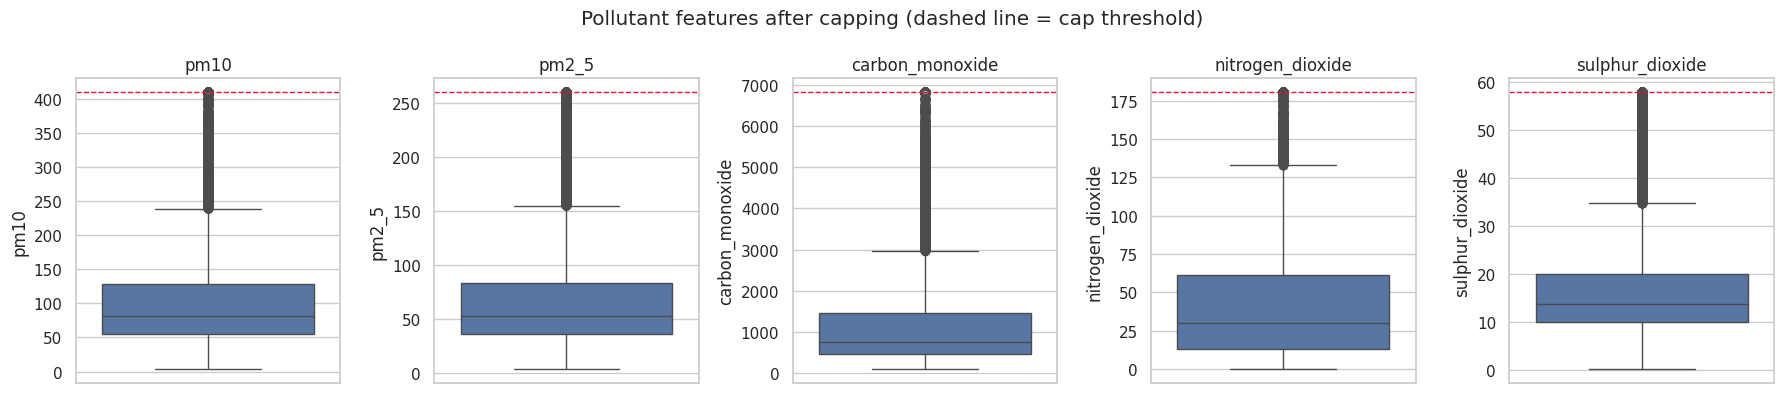

In [ ]:
# Before/after — same box plot style as Section 7, so the effect is directly comparable.
fig, axes = plt.subplots(1, len(OUTLIER_CAP_COLUMNS), figsize=(18, 4))
for ax, col in zip(axes, OUTLIER_CAP_COLUMNS):
    sns.boxplot(y=engineered_df[col], ax=ax)
    ax.set_title(col)
    ax.axhline(outlier_thresholds[col], color='crimson', linestyle='--', linewidth=1)
plt.suptitle('Pollutant features after capping (dashed line = cap threshold)')
plt.tight_layout()
plt.show()